# Municipal Budgets Exploration (2023)

This notebook explores the municipal budget data from [Gobierto Budgets Data](https://github.com/PopulateTools/gobierto-budgets-data).
We are focusing on the **2023 planned budget** for Madrid, Barcelona, and Sevilla using our compiled CSV.

In [4]:
import pandas as pd
import requests
import gzip
from io import BytesIO
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

%matplotlib inline
sns.set_theme(style="whitegrid")


## 1. Configuration & Data Loading

In [3]:
df_budgets = pd.read_csv('../data/municipal_budgets_2023.csv')
display(df_budgets)

,year,type,city,classification,tipreig,code,amount
0,2023,planned,Elche,economic,G,35.00,100000.00
1,2023,planned,Elche,economic,G,213.00,778617.75
2,2023,planned,Elche,economic,G,221.06,10100.00
3,2023,planned,Elche,economic,I,391.00,28000.00
4,2023,planned,Elche,economic,I,114.00,3057000.00
...,...,...,...,...,...,...,...
20510,2023,executed,Sevilla,functional,G,13.00,6674330.95
20511,2023,executed,Sevilla,functional,G,1521.00,522048.89
20512,2023,executed,Sevilla,functional,G,34.00,3662782.31
20513,2023,executed,Sevilla,functional,G,4.00,3657234.00


In [14]:
# Function to extract dictionary mapping from Gobierto SQL
def get_names_mapping(url, table_name, id_col, name_col):
    r = requests.get(url, stream=True)
    mapping = {}
    content = BytesIO(r.content)
    with gzip.GzipFile(fileobj=content) as f:
        for line in f:
            line = line.decode('utf-8', errors='replace')
            if line.startswith(f'INSERT INTO "{table_name}"'):
                match = re.search(r'VALUES \((.*)\);', line)
                if match:
                    parts = re.findall(r"'[^']*'|[^,]+", match.group(1))
                    vals = [v.strip(" '") for v in parts]
                    if len(vals) >= max(id_col, name_col) + 1:
                        mapping[vals[id_col]] = vals[name_col]
    return mapping

print("Loading classification dictionaries (2023)...")
econ_path = '../data/budget_economic_mapping_2023.json'
func_path = '../data/budget_functional_mapping_2023.json'

# Load or Fetch Economic Mapping
if os.path.exists(econ_path):
    with open(econ_path, 'r', encoding='utf-8') as f:
        econ_chapter_map = json.load(f)
    print(f"  ✅ Loaded economic mapping from {econ_path}")
else:
    url = "https://raw.githubusercontent.com/PopulateTools/gobierto-budgets-data/master/data/presupuestos_municipales/2023/planned/tb_cuentasEconomica.sql.gz"
    econ_chapter_map = get_names_mapping(url, 'tb_cuentasEconomica', 1, 2)
    with open(econ_path, 'w', encoding='utf-8') as f:
        json.dump(econ_chapter_map, f, ensure_ascii=False, indent=2)
    print(f"  ☁️  Fetched and saved economic mapping to {econ_path}")

# Load or Fetch Functional Mapping
if os.path.exists(func_path):
    with open(func_path, 'r', encoding='utf-8') as f:
        func_map = json.load(f)
    print(f"  ✅ Loaded functional mapping from {func_path}")
else:
    url = "https://raw.githubusercontent.com/PopulateTools/gobierto-budgets-data/master/data/presupuestos_municipales/2023/planned/tb_cuentasProgramas.sql.gz"
    func_map = get_names_mapping(url, 'tb_cuentasProgramas', 0, 1)
    with open(func_path, 'w', encoding='utf-8') as f:
        json.dump(func_map, f, ensure_ascii=False, indent=2)
    print(f"  ☁️  Fetched and saved functional mapping to {func_path}")


Loading classification dictionaries (2023)...
  ✅ Loaded economic mapping from ../data/budget_economic_mapping_2023.json
  ✅ Loaded functional mapping from ../data/budget_functional_mapping_2023.json


In [16]:
import pandas as pd

# 1. Cargamos el CSV que generamos con el script
df_budgets = pd.read_csv('../data/municipal_budgets_2023.csv')

# 2. Creamos df_target filtrando solo lo que nos interesa para este análisis
df_target = df_budgets[
    (df_budgets['year'] == 2023) & 
    (df_budgets['type'] == 'executed') & 
    (df_budgets['city'].isin(['Madrid', 'Barcelona', 'Sevilla']))
]

print("✅ df_target cargado correctamente.")
print(f"Ciudades en el set: {df_target['city'].unique()}")

# --- CONFIGURACIÓN ---
CIUDAD_A_VER = 'Madrid'  # <--- Cambia esto por 'Barcelona' o 'Sevilla'
# ---------------------

def check_budget(city):
    df_city_func = df_target[
        (df_target['city'] == city) & 
        (df_target['classification'] == 'functional') & 
        (df_target['tipreig'] == 'G')
    ].copy()
    
    df_city_func['code_str'] = df_city_func['code'].astype(int).astype(str)
    df_city_func['Descripción'] = df_city_func['code_str'].map(func_map).fillna("Código desconocido")
    
    print(f"\n✅ Mostrando Gastos Funcionales de: {city}")
    display(df_city_func[['code_str', 'Descripción', 'amount']].sort_values(by='amount', ascending=False).head(20))

check_budget(CIUDAD_A_VER)


✅ df_target cargado correctamente.
Ciudades en el set: ['Barcelona' 'Madrid' 'Sevilla']

✅ Mostrando Gastos Funcionales de: Madrid


,code_str,Descripción,amount
15757,1,SERVICIOS PÚBLICOS BÁSICOS,1.334149e+09
18559,1,SERVICIOS PÚBLICOS BÁSICOS,7.963783e+08
17138,16,Bienestar comunitario,7.493020e+08
15747,13,Seguridad y movilidad ciudadana,6.581186e+08
18575,2,ACTUACIONES DE PROTECCIÓN Y PROMOCIÓN SOCIAL,4.331461e+08
18569,231,Asistencia social primaria,4.331461e+08
19025,23,Servicios Sociales y promoción social,4.331461e+08
18071,132,Seguridad y Orden Público,4.018556e+08
19957,9,ACTUACIONES DE CARÁCTER GENERAL,3.830225e+08
17136,162,Recogida,3.187111e+08


In [17]:
# Filtramos solo gastos funcionales
df_func = df_target[
    (df_target['classification'] == 'functional') & 
    (df_target['tipreig'] == 'G')
].copy()

# Calculamos el nivel de detalle (1, 2, 3 o 4 dígitos)
df_func['nivel'] = df_func['code'].astype(int).astype(str).str.len()

# Creamos una tabla resumen: Ciudades x Nivel de detalle
resumen_filas = df_func.groupby(['city', 'nivel']).size().unstack(fill_value=0)
resumen_filas.columns = [f'{c} dígito(s)' for c in resumen_filas.columns]

print("--- NÚMERO DE FILAS DE GASTO POR CIUDAD Y NIVEL ---")
display(resumen_filas)


--- NÚMERO DE FILAS DE GASTO POR CIUDAD Y NIVEL ---


,1 dígito(s),2 dígito(s),3 dígito(s),4 dígito(s)
city,,,,
Barcelona,33,71,161,34
Madrid,33,78,189,40
Sevilla,32,80,143,31


# 2. Interactive Budget Dashboard (Selectable City & Subdivisions)
Select a city from the dropdown below to instantly re-render horizontal bar plots across all granularity levels.

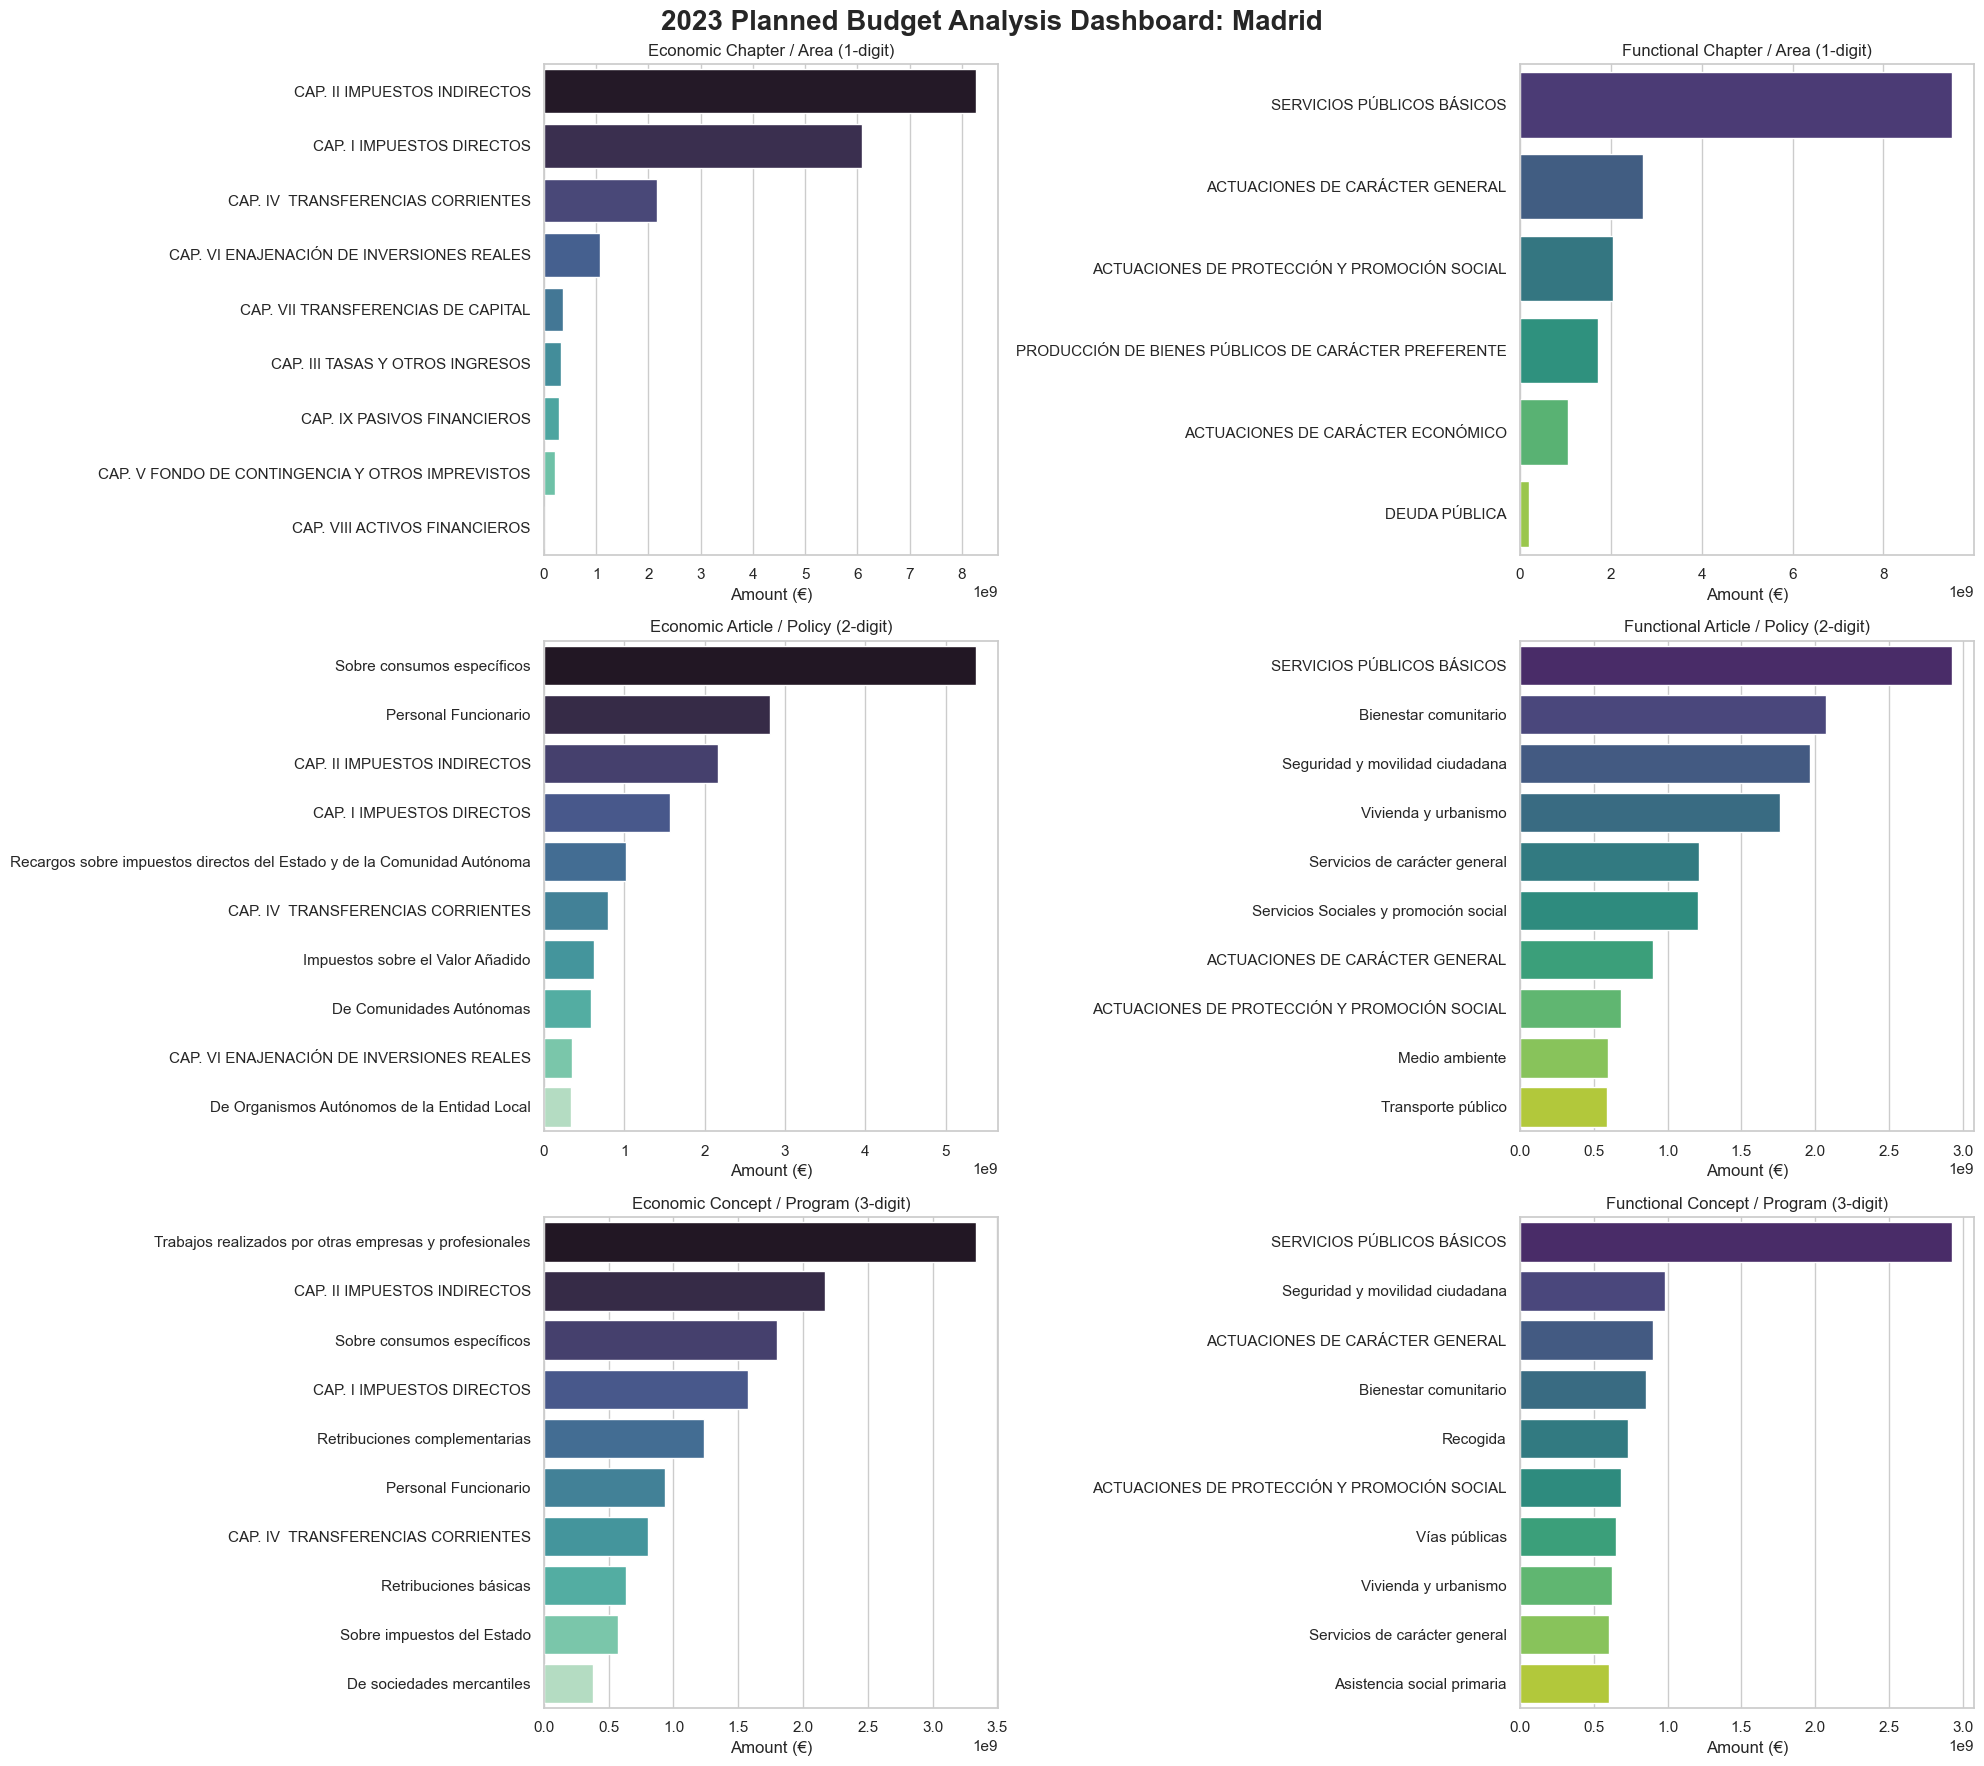

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def plot_city_dashboard(city):
    clear_output(wait=True) # Clears the previous plots cleanly
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    fig.suptitle(f'2023 Planned Budget Analysis Dashboard: {city}', fontsize=20, weight='bold')

    city_data = df_target[df_target['city'] == city]
    df_econ = city_data[(city_data['classification'] == 'economic') & (city_data['tipreig'] == 'G')]
    df_func = city_data[(city_data['classification'] == 'functional') & (city_data['tipreig'] == 'G')]
    
    levels = [
        ('Economic', df_econ, econ_chapter_map, 'mako'),
        ('Functional', df_func, func_map, 'viridis')
    ]
    
    for col, (name, df, mapping, palette) in enumerate(levels):
        for row, max_digits in enumerate([1, 2, 3]):
            df_g = df.copy()
            # 1-digit (Chapter/Policy Area), 2-digit (Article/Policy), 3-digit (Concept/Program)
            df_g['level_code'] = df_g['code'].astype(int).astype(str).str[:max_digits]
            grouped = df_g.groupby('level_code')['amount'].sum().reset_index()
            grouped['Category'] = grouped['level_code'].map(mapping).fillna(grouped['level_code'])
            # Top 10 for displaying cleanly horizontally
            grouped = grouped.sort_values(by='amount', ascending=False).head(10)
            
            ax = axes[row, col]
            sns.barplot(data=grouped, x='amount', y='Category', ax=ax, palette=palette, hue='Category', legend=False)
            level_names = ['Chapter / Area (1-digit)', 'Article / Policy (2-digit)', 'Concept / Program (3-digit)']
            ax.set_title(f'{name} {level_names[row]}')
            ax.set_xlabel('Amount (€)')
            ax.set_ylabel('')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

plot_city_dashboard('Madrid')

# 3. BikesForCities: Advanced Mobility Investment Analysis
As a modern mobility application, we are uniquely interested in how cities allocate funding between **Sustainable Public/Active Mobility** vs **Traditional Car/Traffic Infrastructure**.

We will isolate 3-digit Functional Programs:
- **Sustainable Mobility**: `134` (Urban Mobility), `441` (Passenger Transport), `442` (Transport Infrastructure)
- **Traditional Traffic/Logistics**: `133` (Traffic/Parking Management), `453` (Highways/Roads), `153` (Public Street Paving)

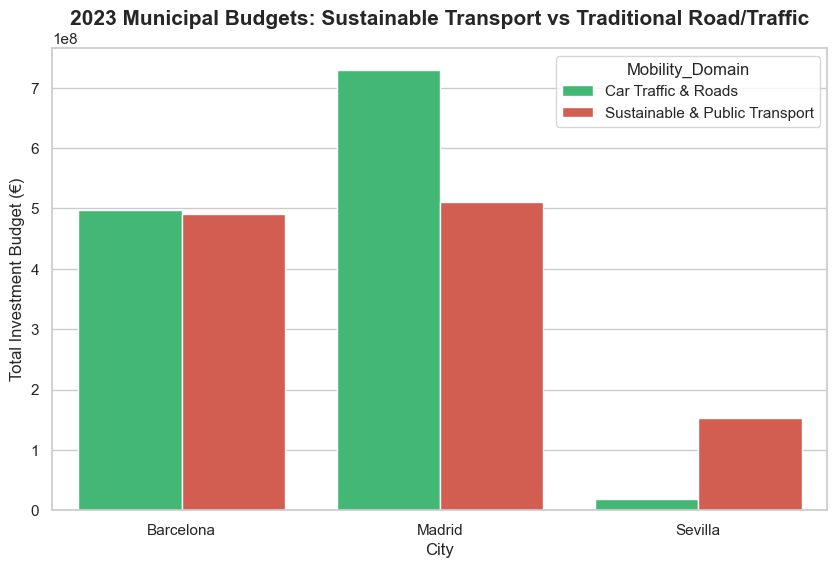

Mobility_Domain,Mobility Sustainability Score (%)
city,
Sevilla,89.380705
Barcelona,49.683038
Madrid,41.227299


In [21]:
# Define mobility functional domains
sustainable_codes = ['134', '441', '442']
car_codes = ['133', '453', '153']

df_func_all = df_target[(df_target['classification'] == 'functional') & (df_target['tipreig'] == 'G')].copy()
df_func_all['program_code'] = df_func_all['code'].astype(int).astype(str).str[:3]

# Categorize spending
def categorize_mobility(code):
    if code in sustainable_codes: return 'Sustainable & Public Transport'
    if code in car_codes: return 'Car Traffic & Roads'
    return 'Other Municipal'

df_func_all['Mobility_Domain'] = df_func_all['program_code'].apply(categorize_mobility)
df_mobility = df_func_all[df_func_all['Mobility_Domain'] != 'Other Municipal']

# Aggregate by city and domain
mob_grouped = df_mobility.groupby(['city', 'Mobility_Domain'])['amount'].sum().reset_index()

# Visualize Domain Comparison!
plt.figure(figsize=(10, 6))
sns.barplot(data=mob_grouped, x='city', y='amount', hue='Mobility_Domain', palette=['#2ECC71', '#E74C3C'])
plt.title('2023 Municipal Budgets: Sustainable Transport vs Traditional Road/Traffic', fontsize=15, weight='bold')
plt.xlabel('City')
plt.ylabel('Total Investment Budget (€)')
plt.show()

# Calculate % Ratios
pivot = mob_grouped.pivot(index='city', columns='Mobility_Domain', values='amount').fillna(0)
pivot['Mobility Sustainability Score (%)'] = (pivot['Sustainable & Public Transport'] / 
                                              (pivot['Sustainable & Public Transport'] + pivot['Car Traffic & Roads']) * 100)
display(pivot[['Mobility Sustainability Score (%)']].sort_values(by='Mobility Sustainability Score (%)', ascending=False))

# 4. Budget Hierarchy Visualization (Sunburst)
A Sunburst plot provides an intuitive way to explore the budget hierarchy, drilling down from Chapter to Article and into Concepts.

In [26]:
import plotly.express as px

# 1. Filtramos datos
df_sun = df_target[(df_target['city'] == 'Barcelona') & 
                   (df_target['classification'] == 'functional') & 
                   (df_target['tipreig'] == 'G')].copy()

df_sun['code_str'] = df_sun['code'].astype(int).astype(str)

# 2. Funciones de jerarquía hasta 4 niveles
def get_l1(x): return f"{x[:1]} - {func_map.get(x[:1], 'Área')}"
def get_l2(x): 
    if len(x) >= 2: return f"{x[:2]} - {func_map.get(x[:2], 'Política')}"
    return f"(Gen. L1) {func_map.get(x[:1], 'Área')}"
def get_l3(x): 
    if len(x) >= 3: return f"{x[:3]} - {func_map.get(x[:3], 'Programa')}"
    return f"(Gen. L2) {func_map.get(x[:2], 'Política')}"
def get_l4(x): 
    if len(x) >= 4: return f"{x[:4]} - {func_map.get(x[:4], 'Subprograma')}"
    return f"(Gen. L3) {func_map.get(x[:3], 'Programa')}"

df_sun['Área (L1)'] = df_sun['code_str'].apply(get_l1)
df_sun['Política (L2)'] = df_sun['code_str'].apply(get_l2)
df_sun['Programa (L3)'] = df_sun['code_str'].apply(get_l3)
df_sun['Subprograma (L4)'] = df_sun['code_str'].apply(get_l4)

# 3. Agrupamos con el nuevo nivel
df_agg = df_sun.groupby(['Área (L1)', 'Política (L2)', 'Programa (L3)', 'Subprograma (L4)'])['amount'].sum().reset_index()
df_agg = df_agg[df_agg['amount'] > 0]

# 4. Sunburst con 4 niveles de profundidad
fig = px.sunburst(
    df_agg,
    path=['Área (L1)', 'Política (L2)', 'Programa (L3)', 'Subprograma (L4)'],
    values='amount',
    title='Barcelona 2023: Máximo Detalle de Gasto (4 niveles)',
    color_discrete_sequence=px.colors.qualitative.Prism
)

fig.update_layout(width=1000, height=1000) # Un poco más grande para que quepa el texto
fig.update_traces(textinfo='label+percent parent')
fig.show()


In [28]:
# 1. Obtenemos códigos de Barcelona
df_list = df_target[
    (df_target['city'] == 'Barcelona') & 
    (df_target['classification'] == 'functional') & 
    (df_target['tipreig'] == 'G')
].copy()

df_list['code_str'] = df_list['code'].astype(int).astype(str)

# 2. Construimos la tabla de referencia
rows = []
for code in sorted(df_list['code_str'].unique(), key=lambda x: x.ljust(4, '0')):
    if len(code) >= 3:
        l1, l2, l3 = code[:1], code[:2], code[:3]
        l4 = code if len(code) == 4 else ""
        
        rows.append({
            "Área (L1)": f"{l1} - {func_map.get(l1, '')}",
            "Política (L2)": f"{l2} - {func_map.get(l2, '')}",
            "Programa (3D)": f"{l3} - {func_map.get(l3, '')}",
            "Subprograma (4D)": f"{l4} - {func_map.get(l4, '')}" if l4 else "-"
        })

df_reference = pd.DataFrame(rows).drop_duplicates()

# 3. Mostrar con los nombres de columna correctos
print("--- DICCIONARIO DE PROGRAMAS Y SUBPROGRAMAS ---")
# Usamos los nombres exactos: (3D) y (4D)
display(df_reference.sort_values(['Área (L1)', 'Política (L2)', 'Programa (3D)']))


--- DICCIONARIO DE PROGRAMAS Y SUBPROGRAMAS ---


,Área (L1),Política (L2),Programa (3D),Subprograma (4D)
0,1 - SERVICIOS PÚBLICOS BÁSICOS,13 - Seguridad y movilidad ciudadana,130 - Administración General de la Seguridad y...,-
1,1 - SERVICIOS PÚBLICOS BÁSICOS,13 - Seguridad y movilidad ciudadana,132 - Seguridad y Orden Público,-
2,1 - SERVICIOS PÚBLICOS BÁSICOS,13 - Seguridad y movilidad ciudadana,133 - Ordenación del tráfico y del estacionami...,-
3,1 - SERVICIOS PÚBLICOS BÁSICOS,13 - Seguridad y movilidad ciudadana,134 - Movilidad urbana,-
4,1 - SERVICIOS PÚBLICOS BÁSICOS,13 - Seguridad y movilidad ciudadana,135 - Protección civil,-
5,1 - SERVICIOS PÚBLICOS BÁSICOS,13 - Seguridad y movilidad ciudadana,136 - Servicio de prevención y extinción de in...,-
6,1 - SERVICIOS PÚBLICOS BÁSICOS,15 - Vivienda y urbanismo,150 - Administración General de Vivienda y urb...,-
7,1 - SERVICIOS PÚBLICOS BÁSICOS,15 - Vivienda y urbanismo,151 - Urbanismo:planeamiento,-
8,1 - SERVICIOS PÚBLICOS BÁSICOS,15 - Vivienda y urbanismo,152 - Vivienda.,-
9,1 - SERVICIOS PÚBLICOS BÁSICOS,15 - Vivienda y urbanismo,152 - Vivienda.,1521 - Promoción y gestión de vivienda de prot...
